# `auto_filter` — Test Notebook

Tests `foreblocks/ts_handler/auto_filter.py` against a synthetic noisy time series.

**Sections**
1. Setup & sample signal
2. Individual filter spot-checks
3. `auto_filter` fast run (all fast filters, default weights)
4. `tune_weights` + `auto_filter` with tuned weights
5. Score table inspection
6. Custom filter registration

In [1]:
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)

from foreblocks.ts_handler.auto_filter import (
    ScoringWeights,
    auto_filter,
    bilateral_filter,
    butter_lowpass,
    filter_metrics,
    fft_denoise,
    gaussian_filter,
    hp_filter,
    kalman_rts_smoother,
    lowess_filter,
    moving_average,
    plot_results,
    register_filter,
    savgol_filter,
    ssa_filter,
    suggest_weights,
    tune_weights,
    tv_denoise,
    wavelet_denoise,
)

print("Import OK")


Import OK


/data/dev/foreblocks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Sample signal

A synthetic "true" signal that combines:
- a slow trend (quadratic)
- a dominant seasonal cycle (period 52 — weekly data, annual season)
- a secondary harmonic

Gaussian noise is added to produce the noisy observation.

N=260  noise_std=0.55  SNR≈8.8 dB


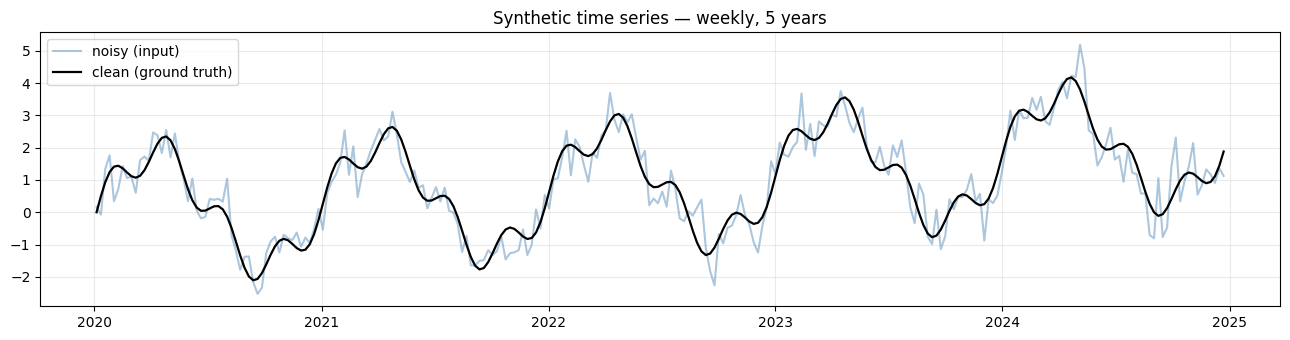

In [2]:
rng = np.random.default_rng(42)
N = 260  # 5 years of weekly data
t = np.arange(N, dtype=float)
dates = pd.date_range("2020-01-01", periods=N, freq="W")

trend     = 0.004 * t + 0.00002 * t**2            # slow upward curve
seasonal  = 1.8 * np.sin(2 * np.pi * t / 52)      # annual cycle
harmonic  = 0.6 * np.sin(2 * np.pi * t / 13)      # quarterly harmonic
clean_arr = trend + seasonal + harmonic

noise_std = 0.55
noise     = rng.normal(0, noise_std, N)
noisy_arr = clean_arr + noise

clean = pd.Series(clean_arr, index=dates, name="clean")
noisy = pd.Series(noisy_arr, index=dates, name="noisy")

snr_db = 10 * np.log10(np.var(clean_arr) / np.var(noise))
print(f"N={N}  noise_std={noise_std}  SNR≈{snr_db:.1f} dB")

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(dates, noisy, alpha=0.45, color="steelblue", label="noisy (input)")
ax.plot(dates, clean, color="black", linewidth=1.6, label="clean (ground truth)")
ax.set_title("Synthetic time series — weekly, 5 years")
ax.legend(); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

## 2. Individual filter spot-checks

Each filter is called directly. We verify:
- output is a `pd.Series` with the same index and length as input
- no NaNs or Infs
- MSE vs the clean signal (informational only — no ground truth required in production)

In [3]:
FILTERS = {
    "Moving Average":       lambda s: moving_average(s, window=11),
    "Gaussian":             lambda s: gaussian_filter(s, sigma=3.0),
    "Savitzky-Golay":       lambda s: savgol_filter(s, window=21, polyorder=3),
    "Butterworth":          lambda s: butter_lowpass(s, cutoff=0.08, order=3),
    "FFT Denoising":        lambda s: fft_denoise(s, cutoff=0.12),
    "Wavelet":              lambda s: wavelet_denoise(s, levels=5, cycle_spins=6),
    "TV Denoising":         lambda s: tv_denoise(s, weight=0.5),
    "LOWESS":               lambda s: lowess_filter(s, frac=0.10),
    "Hodrick-Prescott":     lambda s: hp_filter(s, lamb=1600),
    "SSA":                  lambda s: ssa_filter(s, n_components=4),
    "Kalman RTS":           lambda s: kalman_rts_smoother(s),
    "Bilateral":            lambda s: bilateral_filter(s, sigma_t=6, sigma_v=0.4),
}

rows = []
results = {}
for name, fn in FILTERS.items():
    out = fn(noisy)
    assert isinstance(out, pd.Series), f"{name}: expected pd.Series"
    assert len(out) == len(noisy), f"{name}: length mismatch"
    assert out.index.equals(noisy.index), f"{name}: index mismatch"
    assert not out.isna().any(), f"{name}: contains NaN"
    assert np.isfinite(out.values).all(), f"{name}: contains Inf"
    mse_vs_noisy = float(np.mean((out.values - noisy.values)**2))
    mse_vs_clean = float(np.mean((out.values - clean.values)**2))
    rows.append({"filter": name, "MSE vs clean": mse_vs_clean, "MSE vs noisy": mse_vs_noisy})
    results[name] = out

df_spot = pd.DataFrame(rows).set_index("filter").sort_values("MSE vs clean")
print(df_spot.to_string(float_format="{:.4f}".format))
print("\nAll individual filter checks passed ✓")

                  MSE vs clean  MSE vs noisy
filter                                      
SSA                     0.0633        0.2782
FFT Denoising           0.0774        0.1986
Wavelet                 0.1018        0.1080
TV Denoising            0.1057        0.1183
Kalman RTS              0.1104        0.0628
Gaussian                0.1111        0.2801
Moving Average          0.1520        0.3415
Savitzky-Golay          0.1687        0.3415
Butterworth             0.1830        0.3683
Bilateral               0.2179        0.0148
Hodrick-Prescott        0.2738        0.4873
LOWESS                  0.2764        0.4801

All individual filter checks passed ✓


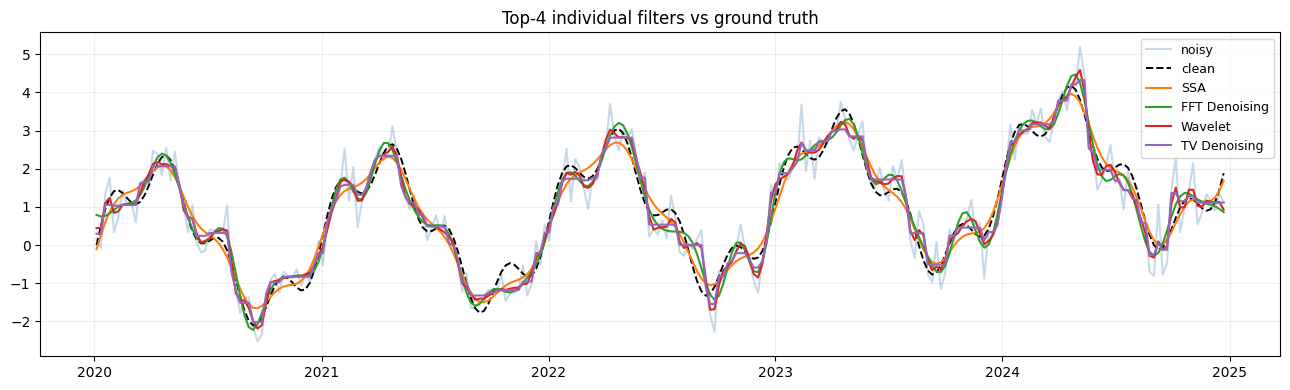

In [4]:
# Plot top-4 by MSE vs clean
top4 = list(df_spot.index[:4])
colors = ["tab:orange", "tab:green", "tab:red", "tab:purple"]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(dates, noisy, alpha=0.3, color="steelblue", label="noisy")
ax.plot(dates, clean, color="black", linewidth=1.4, linestyle="--", label="clean")
for name, c in zip(top4, colors):
    ax.plot(dates, results[name], color=c, linewidth=1.5, label=name)
ax.set_title("Top-4 individual filters vs ground truth")
ax.legend(fontsize=9); ax.grid(alpha=0.2); plt.tight_layout(); plt.show()

## 2b. `filter_metrics` — per-filter quality scores

`filter_metrics` does **not** use the ground truth — it evaluates the denoised signal purely from the noisy input, using four unsupervised criteria:

| Metric | Lower is better | Meaning |
|---|---|---|
| `fidelity_mse` | ✓ | squared deviation from original |
| `roughness` | ✓ | std of first differences |
| `residual_autocorr` | ✓ | structured residual = unremoved signal |
| `derivative_corr` | ✗ (higher is better) | shape preservation |

In [5]:
metric_rows = []
for name, out in results.items():
    m = filter_metrics(out, noisy)
    m["filter"] = name
    metric_rows.append(m)

df_metrics = pd.DataFrame(metric_rows).set_index("filter")
df_metrics = df_metrics[["fidelity_mse", "roughness", "residual_autocorr", "derivative_corr"]]
df_metrics = df_metrics.sort_values("fidelity_mse")
print(df_metrics.to_string(float_format="{:.4f}".format))

                  fidelity_mse  roughness  residual_autocorr  derivative_corr
filter                                                                       
Bilateral               0.0148     0.6332             0.0530           0.9816
Kalman RTS              0.0628     0.3661             0.0762           0.9082
Wavelet                 0.1080     0.3119             0.0730           0.6945
TV Denoising            0.1183     0.3382             0.0748           0.7204
FFT Denoising           0.1986     0.2592             0.0839           0.3571
SSA                     0.2782     0.1796             0.0910           0.3118
Gaussian                0.2801     0.1577             0.1317           0.3171
Savitzky-Golay          0.3415     0.1638             0.2029           0.2219
Moving Average          0.3415     0.1572             0.1761           0.2520
Butterworth             0.3683     0.1504             0.2356           0.2198
LOWESS                  0.4801     0.1177             0.2169    

## 3. `auto_filter` — fast run (default weights)

All non-slow filters are ranked automatically. `fast=True` skips `Denoising Autoencoder` and `CEEMDAN+VMD`.

In [6]:
best_name, best_series, score_table = auto_filter(noisy, fast=True)

print(f"Best filter (default weights, fast=True): {best_name!r}")
print(f"\nScore table (lower score = better rank):")
print(score_table.to_string(float_format="{:.4f}".format))

# Validate outputs
assert isinstance(best_series, pd.Series)
assert len(best_series) == len(noisy)
assert best_series.index.equals(noisy.index)
assert not best_series.isna().any()
print("\nauto_filter output checks passed ✓")

Best filter (default weights, fast=True): 'Kalman RTS'

Score table (lower score = better rank):
                         fidelity_mse  roughness  residual_autocorr  derivative_corr  score
Kalman RTS                     0.0628     0.3661             0.0762           0.9082 0.1923
TV Denoising                   0.0857     0.3812             0.0718           0.8045 0.1923
Bilateral                      0.0557     0.4814             0.0919           0.9543 0.2346
Wavelet (Bayes+Garrote)        0.1054     0.3112             0.0746           0.7075 0.2654
Gaussian                       0.2086     0.1964             0.0782           0.3978 0.3769
EMD+VMD Baseline               0.2339     0.2299             0.0718           0.3513 0.4038
FFT Denoising                  0.1756     0.2867             0.0977           0.3953 0.4423
Savitzky-Golay                 0.2067     0.2489             0.0877           0.3041 0.4846
Butterworth Lowpass            0.2530     0.1790             0.1081        

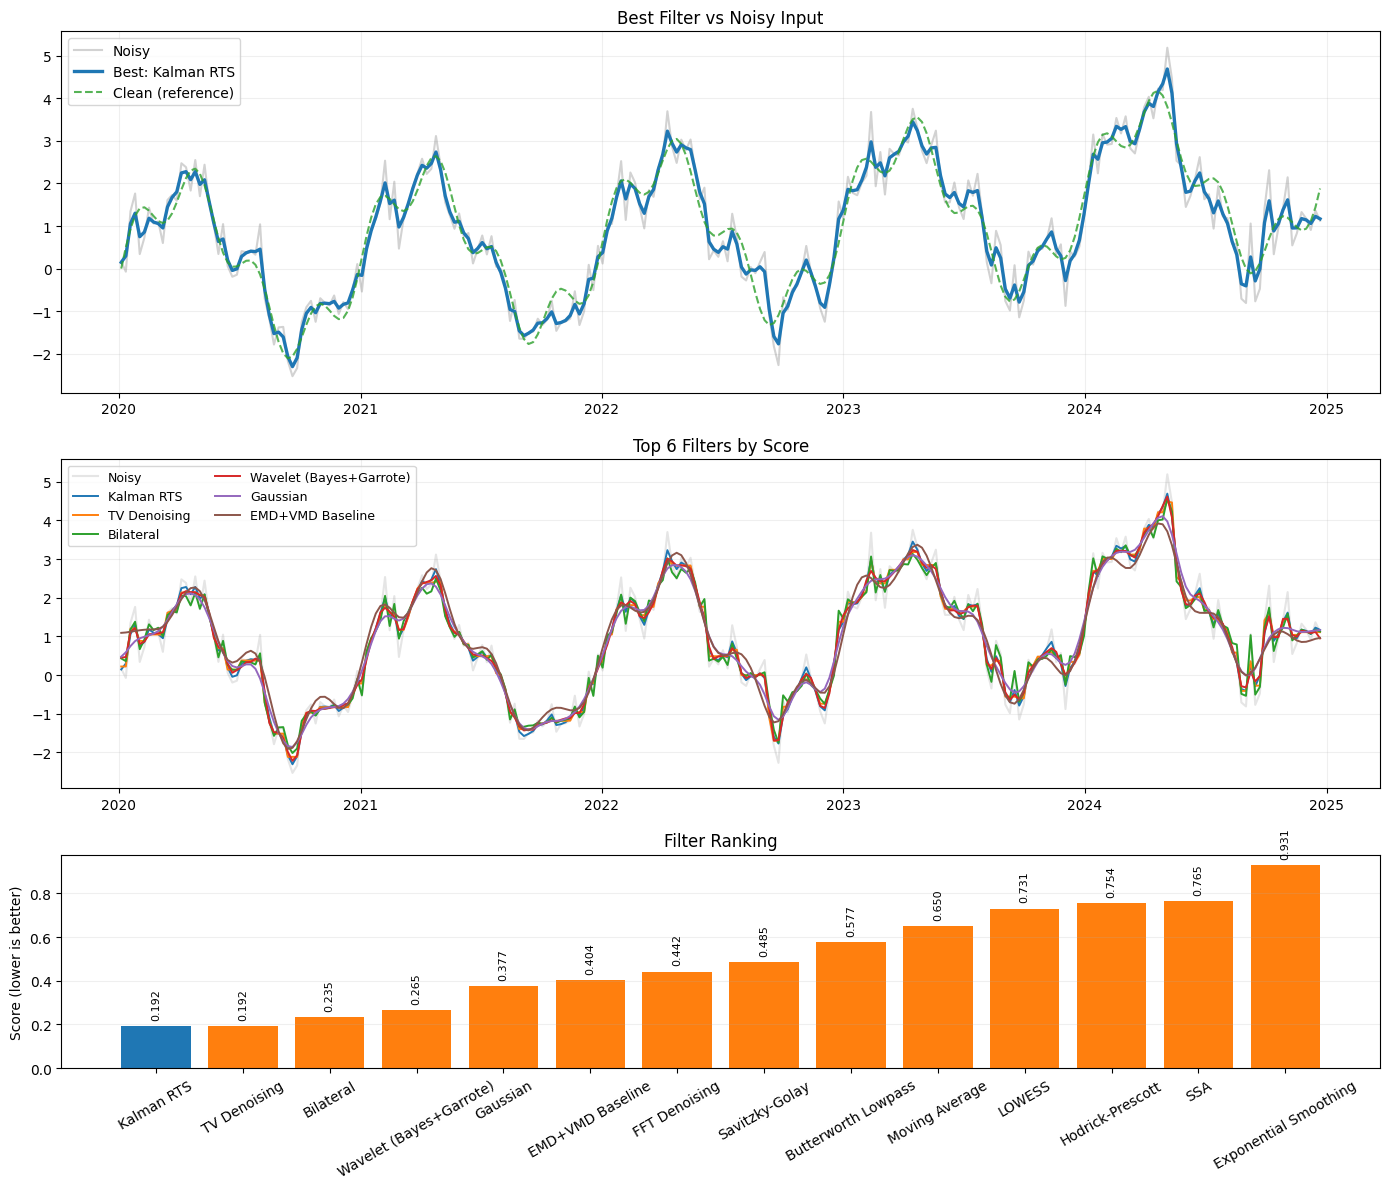

In [7]:
# Re-run auto_filter to get the full candidates dict for plot_results
from foreblocks.ts_handler.auto_filter import _FILTER_REGISTRY, _SLOW_FILTERS

candidates = {}
for name, fn in _FILTER_REGISTRY.items():
    if name in _SLOW_FILTERS:
        continue
    try:
        candidates[name] = fn(noisy)
    except Exception:
        pass

fig = plot_results(noisy, score_table, candidates, best_name, clean=clean, top_k=6)
plt.show()

## 4. Weight strategies: `suggest_weights` → `tune_weights`

Three approaches, increasing in cost:

| Approach | Cost | How |
|---|---|---|
| `ScoringWeights()` | ~0 ms | Fixed defaults (0.40 / 0.10 / 0.25 / 0.25) |
| `suggest_weights(ts)` | ~1 ms | Analyses noise level, periodicity, trend strength analytically |
| `tune_weights(ts, warm_start=True)` | ~30 s | Optuna TPE search, seeded from `suggest_weights` |

`suggest_weights` measures three signal properties:
- **Noise proxy** — MAD of 2nd-differences → boosts `fidelity_mse` when noisy
- **Periodicity** — 1 − normalised spectral entropy → boosts `residual_autocorr` for periodic signals
- **Trend R²** — linear fit quality → boosts `derivative_corr` for trended signals


In [8]:
# ── suggest_weights: heuristic, instant ──────────────────────────────────────
suggested = suggest_weights(noisy)

print("suggest_weights output:")
print(f"  fidelity_mse      = {suggested.fidelity_mse:.4f}")
print(f"  roughness         = {suggested.roughness:.4f}")
print(f"  residual_autocorr = {suggested.residual_autocorr:.4f}")
print(f"  derivative_corr   = {suggested.derivative_corr:.4f}")
print(f"  sum               = {suggested.fidelity_mse + suggested.roughness + suggested.residual_autocorr + suggested.derivative_corr:.6f}")

best_sug, series_sug, table_sug = auto_filter(noisy, fast=True, weights=suggested)
mse_default = float(np.mean((best_series.values - clean.values) ** 2))
mse_sug     = float(np.mean((series_sug.values  - clean.values) ** 2))
print(f"\nBest filter (suggested weights): {best_sug!r}")
print(f"MSE vs clean — default weights  ({best_name}): {mse_default:.4f}")
print(f"MSE vs clean — suggested weights ({best_sug}): {mse_sug:.4f}")


suggest_weights output:
  fidelity_mse      = 0.3620
  roughness         = 0.1015
  residual_autocorr = 0.2612
  derivative_corr   = 0.2753
  sum               = 1.000000

Best filter (suggested weights): 'TV Denoising'
MSE vs clean — default weights  (Kalman RTS): 0.1104
MSE vs clean — suggested weights (TV Denoising): 0.1156


In [9]:
# ── tune_weights: Optuna TPE, warm-started from suggest_weights ──────────────
tuned_weights = tune_weights(noisy, n_trials=60, fast=True, seed=42,
                             warm_start=True, verbose=False)

print("Tuned ScoringWeights (warm_start=True):")
print(f"  fidelity_mse      = {tuned_weights.fidelity_mse:.4f}")
print(f"  roughness         = {tuned_weights.roughness:.4f}")
print(f"  residual_autocorr = {tuned_weights.residual_autocorr:.4f}")
print(f"  derivative_corr   = {tuned_weights.derivative_corr:.4f}")
print(f"  sum               = {tuned_weights.fidelity_mse + tuned_weights.roughness + tuned_weights.residual_autocorr + tuned_weights.derivative_corr:.6f}")


Tuned ScoringWeights (warm_start=True):
  fidelity_mse      = 0.1427
  roughness         = 0.3563
  residual_autocorr = 0.2752
  derivative_corr   = 0.2258
  sum               = 1.000000


In [10]:
best_tuned, series_tuned, table_tuned = auto_filter(noisy, fast=True, weights=tuned_weights)

mse_default = float(np.mean((best_series.values - clean.values) ** 2))
mse_sug     = float(np.mean((series_sug.values  - clean.values) ** 2))
mse_tuned   = float(np.mean((series_tuned.values - clean.values) ** 2))

print(f"Best filter — default weights  ({best_name}):  MSE = {mse_default:.4f}")
print(f"Best filter — suggested weights ({best_sug}): MSE = {mse_sug:.4f}")
print(f"Best filter — tuned weights    ({best_tuned}): MSE = {mse_tuned:.4f}")
print(f"\nTop-5 (tuned weights):")
print(table_tuned.head(5).to_string(float_format="{:.4f}".format))


Best filter — default weights  (Kalman RTS):  MSE = 0.1104
Best filter — suggested weights (TV Denoising): MSE = 0.1156
Best filter — tuned weights    (Gaussian): MSE = 0.0735

Top-5 (tuned weights):
                         fidelity_mse  roughness  residual_autocorr  derivative_corr  score
Gaussian                       0.2086     0.1964             0.0782           0.3978 0.3571
TV Denoising                   0.0857     0.3812             0.0718           0.8045 0.3856
Kalman RTS                     0.0628     0.3661             0.0762           0.9082 0.3934
EMD+VMD Baseline               0.2339     0.2299             0.0718           0.3513 0.3941
Wavelet (Bayes+Garrote)        0.1054     0.3112             0.0746           0.7075 0.4015


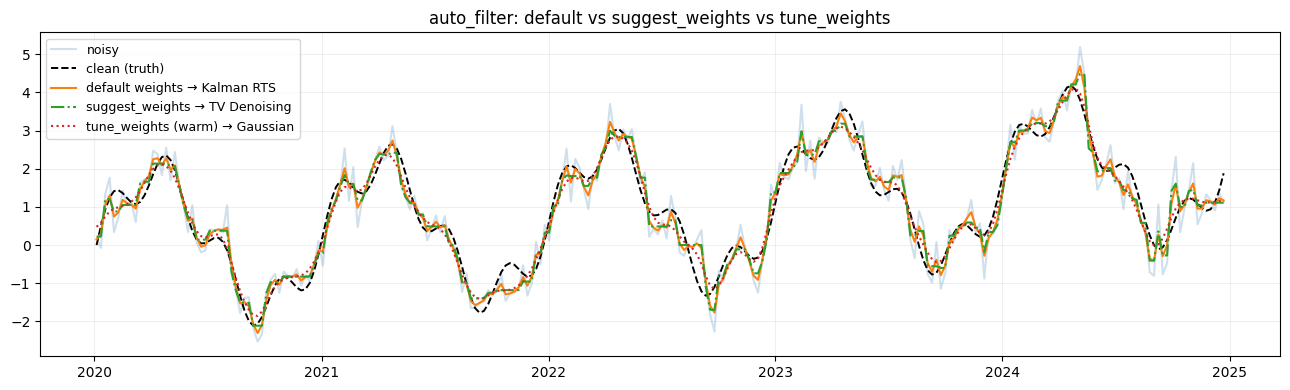

In [11]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(dates, noisy,        alpha=0.25, color="steelblue",  label="noisy")
ax.plot(dates, clean,        color="black", linewidth=1.4, linestyle="--", label="clean (truth)")
ax.plot(dates, best_series,  color="tab:orange", linewidth=1.5,
        label=f"default weights → {best_name}")
ax.plot(dates, series_sug,   color="tab:green",  linewidth=1.5, linestyle="-.",
        label=f"suggest_weights → {best_sug}")
ax.plot(dates, series_tuned, color="tab:red",    linewidth=1.5, linestyle=":",
        label=f"tune_weights (warm) → {best_tuned}")
ax.set_title("auto_filter: default vs suggest_weights vs tune_weights")
ax.legend(fontsize=9); ax.grid(alpha=0.2); plt.tight_layout(); plt.show()


## 5. Score table deep-dive

Inspect which metric drives each filter's ranking. A heatmap makes the tradeoffs visible.

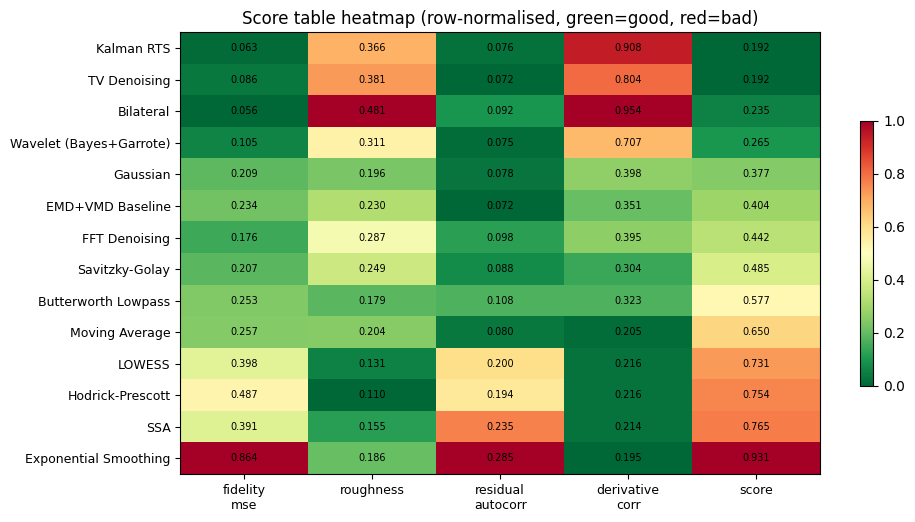

In [12]:
metric_cols = ["fidelity_mse", "roughness", "residual_autocorr", "derivative_corr", "score"]
heat_data = score_table[metric_cols].copy()

# Normalise each column to [0, 1] for visual comparison
norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min() + 1e-12)

fig, ax = plt.subplots(figsize=(10, max(4, len(norm) * 0.38)))
im = ax.imshow(norm.values, aspect="auto", cmap="RdYlGn_r")
ax.set_xticks(range(len(metric_cols)))
ax.set_xticklabels([c.replace("_", "\n") for c in metric_cols], fontsize=9)
ax.set_yticks(range(len(norm)))
ax.set_yticklabels(norm.index, fontsize=9)
ax.set_title("Score table heatmap (row-normalised, green=good, red=bad)")

for i in range(len(norm)):
    for j in range(len(metric_cols)):
        ax.text(j, i, f"{heat_data.values[i, j]:.3f}",
                ha="center", va="center", fontsize=7, color="black")

plt.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout(); plt.show()

## 6. Custom filter registration

The `@register_filter` decorator adds any function with signature `pd.Series → pd.Series` to the auto-ranking pipeline.

In [13]:
from scipy.signal import medfilt

@register_filter("Median (custom)")
def median_filter(ts: pd.Series, kernel_size: int = 9) -> pd.Series:
    """Simple median filter — registered as a custom example."""
    k = kernel_size if kernel_size % 2 == 1 else kernel_size + 1
    k = min(k, len(ts) if len(ts) % 2 == 1 else len(ts) - 1)
    return pd.Series(medfilt(ts.values.astype(float), k), index=ts.index, name="median")

# Verify it now appears in auto_filter
best_c, series_c, table_c = auto_filter(noisy, fast=True)
print(f"Registered filters (fast): {list(table_c.index)}")
assert "Median (custom)" in table_c.index, "Custom filter not found in score table"
median_rank = list(table_c.index).index("Median (custom)") + 1
print(f"\nCustom 'Median' filter rank: {median_rank} / {len(table_c)}")
print("Custom filter registration check passed ✓")

Registered filters (fast): ['Kalman RTS', 'TV Denoising', 'Bilateral', 'Wavelet (Bayes+Garrote)', 'Gaussian', 'EMD+VMD Baseline', 'FFT Denoising', 'Savitzky-Golay', 'Butterworth Lowpass', 'Median (custom)', 'Moving Average', 'LOWESS', 'Hodrick-Prescott', 'SSA', 'Exponential Smoothing']

Custom 'Median' filter rank: 10 / 15
Custom filter registration check passed ✓


## 7. Edge-case checks

Short series, constant series, single spike.

In [14]:
# 7a. Very short series (length = 8)
short = pd.Series(rng.normal(0, 1, 8), name="short")
best_s, out_s, tbl_s = auto_filter(short, fast=True)
assert len(out_s) == 8
print(f"Short series (n=8): best={best_s!r}, output_len={len(out_s)} ✓")

# 7b. Constant series (should return without crashing)
const = pd.Series(np.full(100, 5.0), name="const")
best_co, out_co, _ = auto_filter(const, fast=True)
assert np.allclose(out_co, 5.0, atol=0.1)
print(f"Constant series (n=100): best={best_co!r} ✓")

# 7c. Series with a single large spike
spiked = noisy.copy()
spiked.iloc[130] += 25.0
best_sp, out_sp, _ = auto_filter(spiked, fast=True)
assert np.isfinite(out_sp.values).all()
print(f"Spiked series (n={len(spiked)}): best={best_sp!r}, max output={out_sp.max():.2f} ✓")

print("\nAll edge-case checks passed ✓")

Short series (n=8): best='SSA', output_len=8 ✓
Constant series (n=100): best='Moving Average' ✓
Spiked series (n=260): best='Kalman RTS', max output=15.14 ✓

All edge-case checks passed ✓


/data/dev/foreblocks/.venv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:1380: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/data/dev/foreblocks/.venv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:1387: RuntimeWarning: divide by zero encountered in log
  bic = self.nobs * np.log(sse / self.nobs) + k * np.log(self.nobs)
/data/dev/foreblocks/.venv/lib/python3.12/site-packages/vmdpy/vmdpy.py:105: RuntimeWarning: invalid value encountered in scalar divide
  omega_plus[n+1,k] = np.dot(freqs[T//2:T],(abs(u_hat_plus[n+1, T//2:T, k])**2))/np.sum(abs(u_hat_plus[n+1,T//2:T,k])**2)
/data/dev/foreblocks/.venv/lib/python3.12/site-packages/vmdpy/vmdpy.py:114: RuntimeWarning: invalid value encountered in scalar divide
  omega_plus[n+1,k] = np.dot(freqs[T//2:T],(abs(u_hat_plus[n+1, T//2:T, k])**2))/np.sum(abs(u_hat_plus[n+1,T//2:T,k])**2)
